# 3. Analyse non supervisée des embeddings

Objectif : réduire la dimension des embeddings ResNet, appliquer plusieurs méthodes de clustering, puis évaluer si les groupes obtenus discriminent les images `cancer` et `normal` sur le sous-ensemble fortement labellisé.

In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [2]:
# Charger les features normalisées
FEATURES_PATH = Path("data/processed/resnet18_features.csv")
features_df = pd.read_csv(FEATURES_PATH)
print(features_df.shape)
features_df.head()

(1506, 515)


,path,label,split,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,cancer,avec_labels,0.223682,0.710136,1.481257,0.459431,0.692085,0.185364,2.059628,...,0.113938,1.406707,0.216484,1.110025,1.869285,0.236830,0.708141,0.785015,0.015425,0.529030
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,cancer,avec_labels,2.303200,1.045277,1.294456,2.547840,0.545068,0.133437,1.212342,...,0.162986,0.605513,2.760418,0.387895,1.810046,1.444754,0.330206,1.192759,0.032950,0.648934
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,cancer,avec_labels,3.997212,1.404900,1.149433,0.966352,1.491258,0.024406,1.677062,...,0.545248,1.358088,2.565499,0.517149,2.708174,2.859923,0.957908,1.831673,0.093461,0.461350
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,cancer,avec_labels,2.034307,1.851072,1.561280,0.760116,0.673758,0.079369,3.240707,...,0.443000,0.254960,3.330342,1.184569,0.911555,1.283250,0.122348,0.274706,0.959745,1.228101
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,cancer,avec_labels,2.823692,1.664199,1.330548,1.195984,2.489143,0.071206,2.423799,...,0.522816,0.000000,1.554175,0.503567,0.093622,0.379601,1.066818,1.798177,0.003183,1.693391


In [3]:
# Séparer featurers et métadonnées
feature_columns = [col for col in features_df.columns if col.startswith("feature_")]

X = features_df[feature_columns].values

metadata = features_df[["path", "label", "split"]].copy()

print("Shape X :", X.shape)
metadata["label"].value_counts()

Shape X : (1506, 512)


label
unknown    1406
cancer       50
normal       50
Name: count, dtype: int64

In [4]:
# Normaliser les features pour la PCA et le t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyenne globale après standardisation (proche de 0 attendue):", X_scaled.mean())
print("Écart-type global après standardisation (proche de 1 attendu):", X_scaled.std())
print("Valeurs manquantes (0 attendue):", np.isnan(X_scaled).sum())

Moyenne globale après standardisation (proche de 0 attendue): 2.9084839155653636e-20
Écart-type global après standardisation (proche de 1 attendu): 1.0
Valeurs manquantes (0 attendue): 0


In [5]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Variance expliquée par PC1 :", explained_variance[0])
print("Variance expliquée par PC2 :", explained_variance[1])
print("Variance expliquée par PC3 :", explained_variance[2])
print("Variance cumulée PC1-PC3 :", cumulative_variance[2])

Variance expliquée par PC1 : 0.11070578359902523
Variance expliquée par PC2 : 0.05295060957420295
Variance expliquée par PC3 : 0.04682734923106706
Variance cumulée PC1-PC3 : 0.21048374240429524


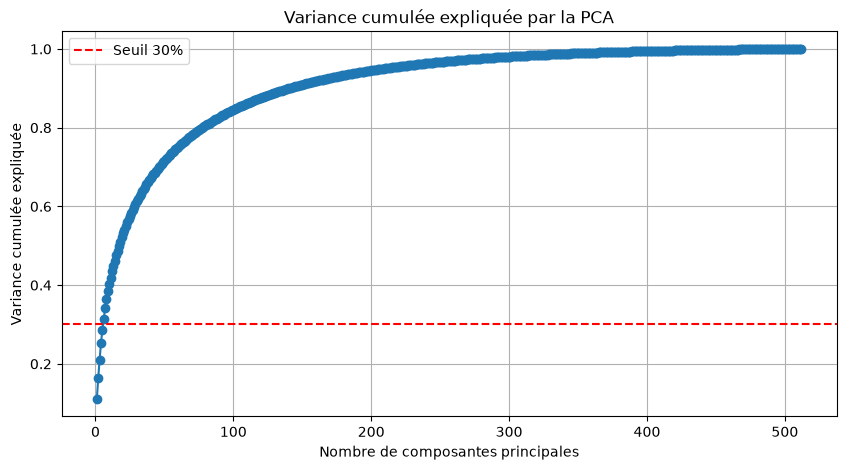

In [6]:
# Plot variance cumulée PCA
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.30, color="red", linestyle="--", label="Seuil 30%")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance cumulée expliquée")
plt.title("Variance cumulée expliquée par la PCA")
plt.legend()
plt.grid(True)
plt.show()

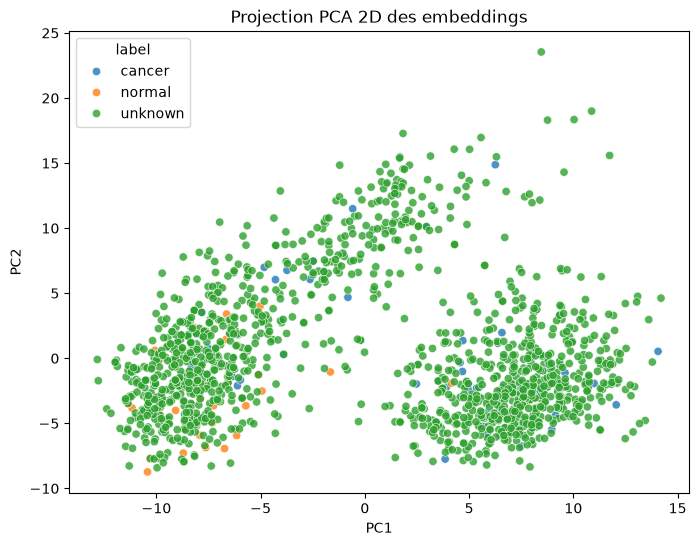

In [7]:
# Projection PCA 2D
viz_df = metadata.copy()
viz_df["PC1"] = X_pca[:, 0]
viz_df["PC2"] = X_pca[:, 1]
viz_df["PC3"] = X_pca[:, 2]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=viz_df,
    x="PC1",
    y="PC2",
    hue="label",
    alpha=0.8
)
plt.title("Projection PCA 2D des embeddings")
plt.show()

In [18]:
# Projection PCA 3D
import plotly.express as px

fig = px.scatter_3d(
    viz_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="label",
    title="Projection PCA 3D des embeddings",
    opacity=0.7,
    hover_data=["path", "label", "split"]
)

fig.update_traces(marker=dict(size=4))
fig.write_html("pca_3d_plot.html")
print("Graphique interactif sauvegardé dans pca_3d_plot.html")
fig.show()

Graphique interactif sauvegardé dans pca_3d_plot.html


La projection PCA 3D permet de vérifier si la troisième composante principale améliore la séparation visuelle des groupes observés en 2D.
- Si les labels `cancer` et `normal` restent mélangés dans les mêmes zones, cela indique que les trois premières composantes ne suffisent pas à discriminer clairement les classes.  
- Si certains groupes deviennent plus séparés en 3D, cela suggère que l'information utile n'était pas entièrement visible sur le plan PC1-PC2. 

Et c'est le cas on cluster relativement bien séparé avec essentiellement des normaux. 

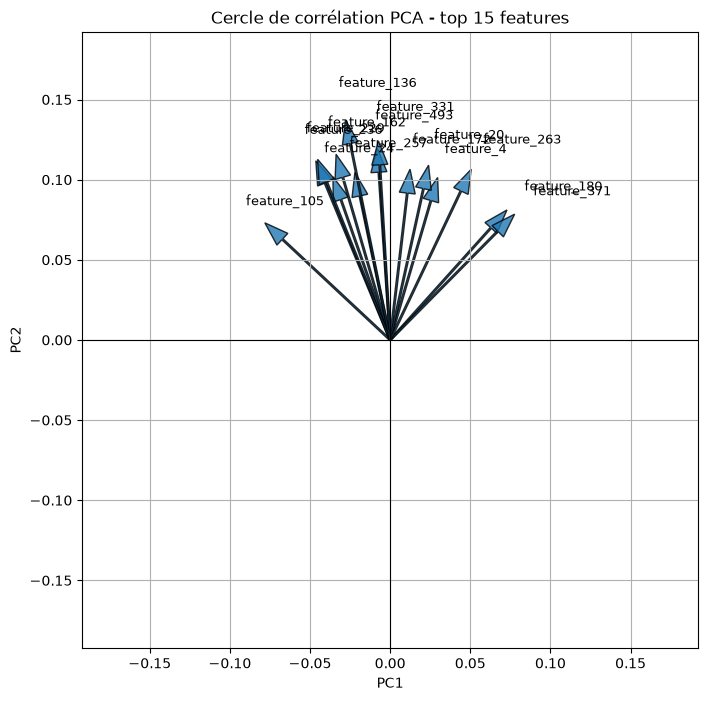

,feature,PC1_loading,PC2_loading,contribution_PC1_PC2
136,feature_136,-0.027858,0.137254,0.019615
331,feature_331,-0.007350,0.124249,0.015492
229,feature_229,-0.045248,0.112691,0.014747
236,feature_236,-0.046390,0.111775,0.014646
162,feature_162,-0.033745,0.115867,0.014564
493,feature_493,-0.008036,0.119639,0.014378
263,feature_263,0.050571,0.106502,0.013900
20,feature_20,0.023977,0.109050,0.012467
371,feature_371,0.077662,0.078479,0.012190
180,feature_180,0.072879,0.081092,0.011887


In [11]:
# Cercle de corrélation PCA
def plot_top_correlation_circle(pca, feature_columns, axis_x=0, axis_y=1, top_n=15):
    loadings = pca.components_.T

    contributions = (
        loadings[:, axis_x] ** 2
        + loadings[:, axis_y] ** 2
    )

    top_indices = np.argsort(contributions)[-top_n:]

    fig, ax = plt.subplots(figsize=(8, 8))

    circle = plt.Circle((0, 0), 1, color="gray", fill=False)
    ax.add_artist(circle)

    for i in top_indices:
        ax.arrow(
            0,
            0,
            loadings[i, axis_x],
            loadings[i, axis_y],
            alpha=0.8,
            head_width=0.01,
            length_includes_head=True
        )
        ax.text(
            loadings[i, axis_x] * 1.15,
            loadings[i, axis_y] * 1.15,
            feature_columns[i],
            fontsize=9
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)

    max_coord = np.max(np.abs(loadings[top_indices][:, [axis_x, axis_y]])) * 1.4
    max_coord = max(max_coord, 0.1)

    ax.set_xlim(-max_coord, max_coord)
    ax.set_ylim(-max_coord, max_coord)

    ax.set_xlabel(f"PC{axis_x + 1}")
    ax.set_ylabel(f"PC{axis_y + 1}")
    ax.set_title(f"Cercle de corrélation PCA - top {top_n} features")
    ax.set_aspect("equal")
    ax.grid(True)

    plt.show()

plot_top_correlation_circle(
    pca,
    feature_columns,
    axis_x=0,
    axis_y=1,
    top_n=15
)

loadings = pca.components_.T

contribution_df = pd.DataFrame({
    "feature": feature_columns,
    "PC1_loading": loadings[:, 0],
    "PC2_loading": loadings[:, 1],
})

contribution_df["contribution_PC1_PC2"] = (
    contribution_df["PC1_loading"] ** 2
    + contribution_df["PC2_loading"] ** 2
)

contribution_df = contribution_df.sort_values(
    "contribution_PC1_PC2",
    ascending=False
)

contribution_df.head(20)

Le cercle de corrélation des 15 features les plus contributrices montre que les variables latentes les plus importantes pour le plan PC1-PC2 contribuent principalement à l'axe PC2.

Les flèches sont orientées dans des directions proches, ce qui indique que ces dimensions ResNet capturent des variations similaires dans les embeddings. Leur contribution à PC1 est plus limitée et répartie entre des directions positives et négatives.

Les longueurs des flèches restent modérées : aucune feature individuelle ne domine fortement la projection PCA. Cela suggère que l'information utile est distribuée sur plusieurs dimensions latentes, ce qui est cohérent avec des embeddings issus d'un CNN pré-entraîné.

Comme les features ResNet ne sont pas des variables métier directement interprétables, ce graphique est utilisé comme un contrôle exploratoire. L'interprétation principale reposera davantage sur la projection PCA des individus, la variance expliquée, l'ARI et la composition des clusters en labels `normal`/`cancer`.

In [ ]:
# t-SNE cumulative variance
pca_3d_information = cumulative_variance[2]

print("Information retenue par les 3 premières composantes PCA :", pca_3d_information)

run_tsne = pca_3d_information >= 0.30
print("Lancer t-SNE :", run_tsne)

Information retenue par les 3 premières composantes PCA : 0.21048374240429524
Lancer t-SNE : False


Nous utilisons PCA et t-SNE de manière complémentaire.  
La PCA permet une réduction linéaire interprétable avec une mesure de variance expliquée.  
t-SNE est utilisé comme outil de visualisation non linéaire pour observer la structure locale des embeddings.

Le choix final des clusters ne se base pas uniquement sur la visualisation, mais sur l'ARI et la composition des clusters sur les données fortement labellisées.

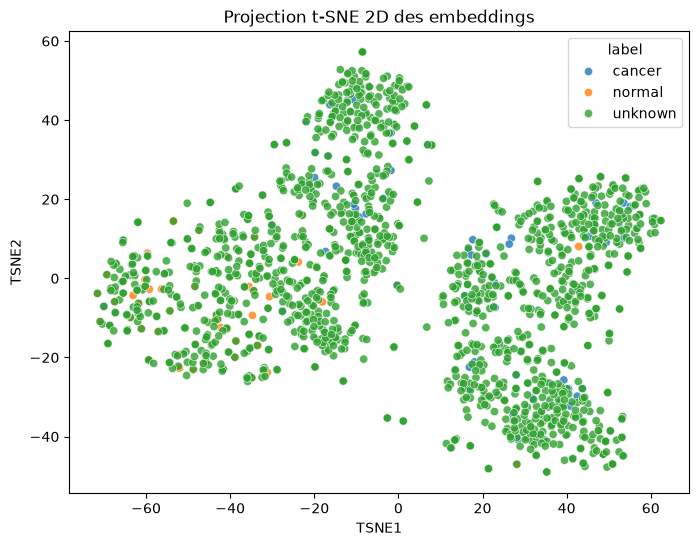

In [13]:
# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

viz_df["TSNE1"] = X_tsne[:, 0]
viz_df["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=viz_df,
    x="TSNE1",
    y="TSNE2",
    hue="label",
    alpha=0.8
)
plt.title("Projection t-SNE 2D des embeddings")
plt.show()

In [17]:
# t-SNE 3D
#import plotly.express as px
tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)
viz_df["TSNE1_3D"] = X_tsne_3d[:, 0]
viz_df["TSNE2_3D"] = X_tsne_3d[:, 1]
viz_df["TSNE3_3D"] = X_tsne_3d[:, 2]
viz_df[["TSNE1_3D", "TSNE2_3D", "TSNE3_3D"]].head()

fig = px.scatter_3d(
    viz_df,
    x="TSNE1_3D",
    y="TSNE2_3D",
    z="TSNE3_3D",
    color="label",
    title="Projection t-SNE 3D des embeddings",
    opacity=0.7,
    hover_data=["path", "label", "split"]
)

fig.update_traces(marker=dict(size=4))
fig.write_html("tsne_3d_plot.html")
print("Graphique interactif sauvegardé dans tsne_3d_plot.html")
fig.show()

Graphique interactif sauvegardé dans tsne_3d_plot.html


La projection t-SNE 3D complète la visualisation t-SNE 2D en ajoutant une dimension de projection supplémentaire.

Contrairement à la PCA, les axes t-SNE ne sont pas directement interprétables : ils ne représentent pas une variance expliquée ni des combinaisons linéaires de features. L'objectif est uniquement de visualiser la structure locale des embeddings.

Si les images `normal` et `cancer` restent mélangées dans les mêmes groupes, cela suggère que les embeddings ResNet ne séparent pas clairement les deux classes sans supervision.  
Si certains groupes sont majoritairement composés d'un label, cela indique une structure exploitable pour une labellisation faible ou semi-supervisée.

L'interprétation finale ne doit pas se baser uniquement sur t-SNE, mais être confirmée avec les métriques de clustering, notamment l'ARI et la distribution des labels connus dans les clusters.

In [19]:
# Préparer l’évaluation ARI sur les labels connus
labeled_mask = features_df["label"].isin(["normal", "cancer"])

X_eval = X_scaled[labeled_mask]
y_true = features_df.loc[labeled_mask, "label"].map({
    "normal": 0,
    "cancer": 1
}).values

print("Nombre d'images fortement labellisées :", len(y_true))
print(pd.Series(y_true).value_counts())

Nombre d'images fortement labellisées : 100
1    50
0    50
Name: count, dtype: int64


In [20]:
# k-means clustering de k=2 à k=10 et évaluation ARI et silhouette score
kmeans_results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels_all = kmeans.fit_predict(X_scaled)
    cluster_labels_eval = cluster_labels_all[labeled_mask]

    ari = adjusted_rand_score(y_true, cluster_labels_eval)

    silhouette = silhouette_score(X_scaled, cluster_labels_all)

    kmeans_results.append({
        "k": k,
        "ari": ari,
        "silhouette": silhouette
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df

,k,ari,silhouette
0,2,0.404052,0.092802
1,3,0.414866,0.102790
2,4,0.341438,0.096688
3,5,0.283094,0.064836
4,6,0.348454,0.065540
5,7,0.208039,0.065831
6,8,0.209231,0.063513
7,9,0.189482,0.068640
8,10,0.183743,0.072373


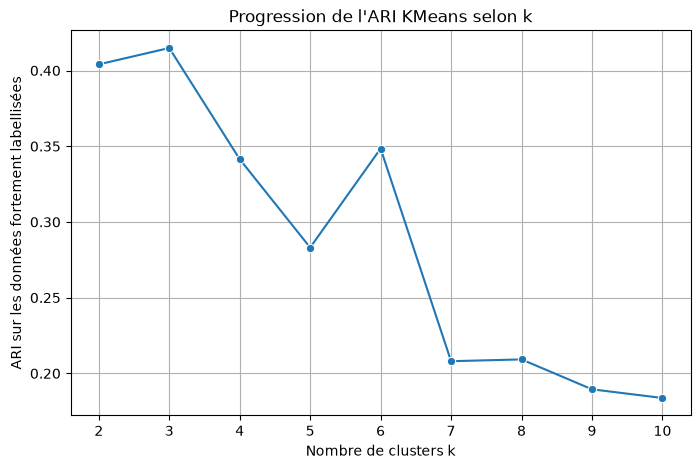

In [21]:
# Plot de la progression de l'ARI selon k
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="ari",
    marker="o"
)
plt.title("Progression de l'ARI KMeans selon k")
plt.xlabel("Nombre de clusters k")
plt.ylabel("ARI sur les données fortement labellisées")
plt.grid(True)
plt.show()

In [22]:
# Choix du meilleur k basé sur l'ARI
best_k = kmeans_results_df.sort_values("ari", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Meilleur k selon ARI :", best_k)

Meilleur k selon ARI : 3


In [ ]:
# Clustering k-means final avec le meilleur k
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

features_df["cluster_kmeans"] = best_kmeans.fit_predict(X_scaled)

kmeans_ari = adjusted_rand_score(
    y_true,
    features_df.loc[labeled_mask, "cluster_kmeans"]
)

print("ARI KMeans optimal :", kmeans_ari)

ARI KMeans optimal : 0.4148663717573247


C:\Users\louis\AppData\Local\Temp\ipykernel_16456\2673132718.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df["cluster_kmeans"] = best_kmeans.fit_predict(X_scaled)


label,cancer,normal
cluster_kmeans,,
0,0.935484,0.064516
1,0.200000,0.800000
2,1.000000,0.000000


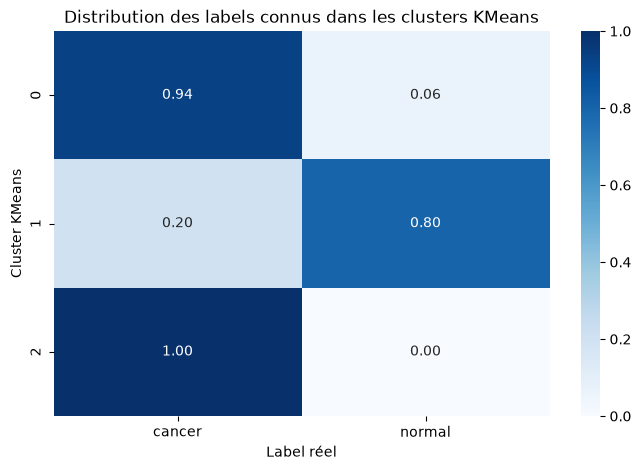

In [24]:
# Distribution des labels dans les clusters KMeans
kmeans_distribution = pd.crosstab(
    features_df.loc[labeled_mask, "cluster_kmeans"],
    features_df.loc[labeled_mask, "label"],
    normalize="index"
)

display(kmeans_distribution)

plt.figure(figsize=(8, 5))
sns.heatmap(kmeans_distribution, annot=True, cmap="Blues", fmt=".2f")
plt.title("Distribution des labels connus dans les clusters KMeans")
plt.xlabel("Label réel")
plt.ylabel("Cluster KMeans")
plt.show()

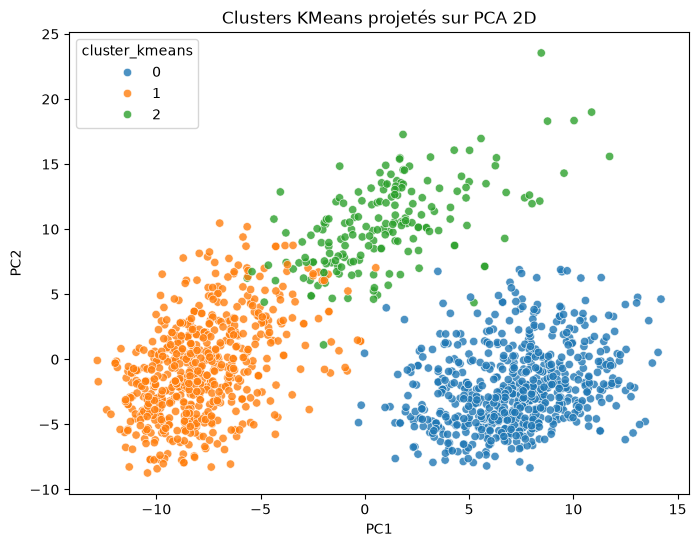

In [25]:
# Visualisation PCA avec clusters KMeans
viz_df["cluster_kmeans"] = features_df["cluster_kmeans"].astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=viz_df,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    alpha=0.8
)
plt.title("Clusters KMeans projetés sur PCA 2D")
plt.show()

In [26]:
# Visualisation PCA 3D avec clusters KMeans
import plotly.express as px

viz_df["cluster_kmeans"] = features_df["cluster_kmeans"].astype(str)

fig = px.scatter_3d(
    viz_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster_kmeans",
    symbol="label",
    title="Clusters KMeans projetés sur PCA 3D",
    opacity=0.7,
    hover_data=["path", "label", "split"]
)

fig.update_traces(marker=dict(size=4))
fig.show()

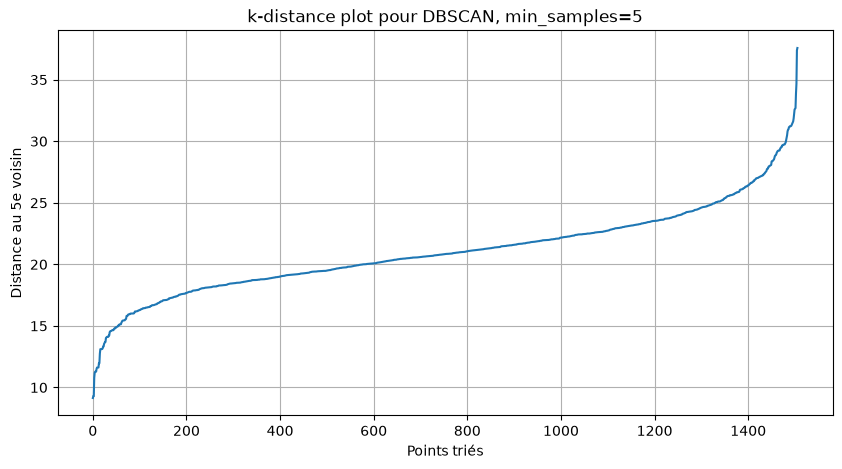

In [ ]:
# Prépareration des paramètres pour DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f"k-distance plot pour DBSCAN, min_samples={min_samples}")
plt.xlabel("Points triés")
plt.ylabel(f"Distance au {min_samples}e voisin")
plt.grid(True)
plt.show()

On cherche un coude dans la courbe. La valeur de distance au niveau du coude est un bon candidat pour `eps`. ici C'est environ 21. 

In [30]:
# recherche des meilleurs paramètres pour DBSCAN autour de esp = 21
eps_values = np.arange(18, 25, 0.5)
min_samples_values = [3, 5, 8, 10, 12, 15, 20, 25, 30]

dbscan_local_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_dbscan = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
        noise_ratio = np.mean(labels_dbscan == -1)

        ari = adjusted_rand_score(
            y_true,
            labels_dbscan[labeled_mask]
        )

        dbscan_local_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "ari": ari
        })

dbscan_local_results_df = pd.DataFrame(dbscan_local_results)

dbscan_local_results_df.sort_values("ari", ascending=False).head(20)

,eps,min_samples,n_clusters,noise_ratio,ari
67,21.5,12,2,0.361886,0.213601
45,20.5,3,28,0.305445,0.205101
68,21.5,15,2,0.378486,0.199858
18,19.0,3,46,0.480744,0.197469
27,19.5,3,44,0.416335,0.194231
69,21.5,20,2,0.415671,0.194213
36,20.0,3,36,0.361886,0.185062
59,21.0,15,2,0.450863,0.179857
57,21.0,10,2,0.406375,0.176863
71,21.5,30,2,0.462151,0.172208


In [31]:
# DBSCAN clustering avec les meilleurs paramètres trouvés
dbscan = DBSCAN(
    eps=21.5,
    min_samples=12
)

features_df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

features_df["cluster_dbscan"].value_counts()

cluster_dbscan
 1    605
-1    545
 0    356
Name: count, dtype: int64

In [33]:
# Distribution des labels dans les clusters DBSCAN
best_dbscan = DBSCAN(
    eps=21.5,
    min_samples=12
)

features_df["cluster_dbscan"] = best_dbscan.fit_predict(X_scaled)

dbscan_counts = pd.crosstab(
    features_df.loc[labeled_mask, "cluster_dbscan"],
    features_df.loc[labeled_mask, "label"]
)

dbscan_distribution = pd.crosstab(
    features_df.loc[labeled_mask, "cluster_dbscan"],
    features_df.loc[labeled_mask, "label"],
    normalize="index"
)

display(dbscan_counts)
display(dbscan_distribution)

label,cancer,normal
cluster_dbscan,,
-1,15,12
0,23,1
1,12,37


label,cancer,normal
cluster_dbscan,,
-1,0.555556,0.444444
0,0.958333,0.041667
1,0.244898,0.755102


Le meilleur paramétrage DBSCAN identifie deux clusters exploitables, mais rejette aussi une partie importante des images comme bruit (`-1`).

Le cluster 0 est très majoritairement composé d'images `cancer`, ce qui indique que DBSCAN détecte une sous-structure pertinente pour une partie des cas cancéreux. Le cluster 1 est majoritairement composé d'images `normal`, mais avec une pureté plus faible.

Cependant, le groupe `-1` contient un mélange de labels `cancer` et `normal`, ce qui limite l'intérêt de DBSCAN pour une labellisation faible complète du dataset. Contrairement à KMeans, DBSCAN ne fournit pas une affectation exploitable pour toutes les images.

DBSCAN semble donc utile pour identifier certains groupes très denses et relativement purs, mais moins adapté que KMeans comme méthode principale de clustering sur ces embeddings.

In [32]:
# Evaluation de l'ARI pour DBSCAN
dbscan_eval_labels = features_df.loc[labeled_mask, "cluster_dbscan"]

dbscan_ari = adjusted_rand_score(y_true, dbscan_eval_labels)

print("ARI DBSCAN :", dbscan_ari)
print("ARI KMeans optimal :", kmeans_ari)

ARI DBSCAN : 0.21360081521405508
ARI KMeans optimal : 0.4148663717573247


Le meilleur paramétrage DBSCAN trouvé est `eps=21.5` et `min_samples=12`. Il produit deux clusters avec un taux de bruit d'environ 36% et un ARI d'environ 0.214.

Même optimisé, DBSCAN reste moins performant que KMeans, qui obtient un ARI d'environ 0.415. DBSCAN capte donc une structure partielle, mais il discrimine moins bien les labels connus `normal` et `cancer` que KMeans.

Je garde DBSCAN comme comparaison, mais choisis KMeans comme méthode non supervisée principale.

## Interprétation des clusters

La qualité du clustering est évaluée avec l'ARI sur les données fortement labellisées, c'est-à-dire uniquement les images `normal` et `cancer`.

Un bon clustering devrait produire des groupes où la distribution des labels est très déséquilibrée :
- certains clusters contenant principalement des images `cancer` ;
- d'autres clusters contenant principalement des images `normal`.

Si les clusters contiennent des proportions proches de 50% `normal` et 50% `cancer`, alors les regroupements ne discriminent pas bien les deux classes médicales.

L'ARI permet de quantifier l'accord entre les clusters non supervisés et les labels connus. Un ARI proche de 1 indique un très bon accord, tandis qu'un ARI proche de 0 indique un regroupement proche du hasard.

In [44]:
# Ajout des projections PCA et t-SNE dans le DataFrame final
features_df["PC1"] = viz_df["PC1"]
features_df["PC2"] = viz_df["PC2"]
features_df["PC3"] = viz_df["PC3"]
features_df["TSNE1"] = viz_df["TSNE1"]
features_df["TSNE2"] = viz_df["TSNE2"]
features_df["TSNE1_3D"] = viz_df["TSNE1_3D"]
features_df["TSNE2_3D"] = viz_df["TSNE2_3D"]
features_df["TSNE3_3D"] = viz_df["TSNE3_3D"]

features_df.head(10)

,path,label,split,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,cluster_kmeans,cluster_dbscan,PC1,PC2,PC3,TSNE1,TSNE2,TSNE1_3D,TSNE2_3D,TSNE3_3D
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,cancer,avec_labels,0.223682,0.710136,1.481257,0.459431,0.692085,0.185364,2.059628,...,0,0,8.396483,-2.436171,7.176140,42.510120,-29.786404,21.015488,-17.777609,1.802920
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,cancer,avec_labels,2.303200,1.045277,1.294456,2.547840,0.545068,0.133437,1.212342,...,1,1,-8.551546,-4.022785,-2.804376,-9.233247,15.479722,-2.821812,6.201744,7.743299
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,cancer,avec_labels,3.997212,1.404900,1.149433,0.966352,1.491258,0.024406,1.677062,...,1,1,-6.108632,-2.111135,-3.556742,-3.443153,20.144793,1.201895,10.207444,9.279955
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,cancer,avec_labels,2.034307,1.851072,1.561280,0.760116,0.673758,0.079369,3.240707,...,2,-1,-1.963537,6.659886,-0.570339,-19.801159,31.811998,-6.846777,16.701790,-8.202891
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,cancer,avec_labels,2.823692,1.664199,1.330548,1.195984,2.489143,0.071206,2.423799,...,2,-1,6.257315,14.876310,-4.353542,-1.743610,36.785706,8.053403,20.339365,4.648187
5,data\raw\avec_labels\cancer\27149ff6-8363-4942...,cancer,avec_labels,0.339946,0.205977,1.146863,1.454705,0.491577,0.000000,2.562411,...,0,0,12.054579,-3.577687,-1.164138,53.528648,10.193207,24.978411,8.192469,0.095882
6,data\raw\avec_labels\cancer\2b810835-844c-49ff...,cancer,avec_labels,0.251919,0.654332,1.412932,2.371946,2.703852,0.003507,1.874744,...,0,-1,4.567610,-0.338080,-7.894028,26.850080,10.146668,8.263161,6.962588,-15.088655
7,data\raw\avec_labels\cancer\2d662cc1-509b-4657...,cancer,avec_labels,1.503569,0.793949,0.828595,2.099333,1.154162,0.000000,3.520046,...,0,-1,4.699865,1.356945,-1.695741,17.691069,9.782521,3.982003,2.528121,-20.928823
8,data\raw\avec_labels\cancer\2fa551e9-5b85-44f6...,cancer,avec_labels,0.397270,0.353978,0.543069,1.376310,0.284503,0.046021,1.333921,...,0,0,5.841113,-4.180167,4.935919,28.405275,-40.708122,9.704277,-23.213297,4.240356
9,data\raw\avec_labels\cancer\3c3d07cb-ec2a-43b0...,cancer,avec_labels,2.969292,0.744379,1.561141,1.361955,0.216016,0.000000,3.424394,...,1,1,-7.524073,0.798998,-3.543282,-17.295683,6.789665,0.631923,-0.224854,4.662183


In [45]:
# Sauvegarder les résultats
OUTPUT_PATH = Path("data/processed/clustering_results.csv")

features_df.to_csv(OUTPUT_PATH, index=False)

print("Résultats sauvegardés :", OUTPUT_PATH)

Résultats sauvegardés : data\processed\clustering_results.csv


## Definition of Done - Étape 3

L'étape 3 est considérée comme terminée si :

- les features ResNet sont standardisées ;
- une PCA est réalisée ;
- la variance cumulée PCA est visualisée ;
- un cercle de corrélation PCA est produit ;
- t-SNE est utilisé pour visualiser les embeddings de manière 2D et 3D en complément de la PCA;
- KMeans est testé pour k allant de 2 à 10 ;
- le meilleur k est sélectionné avec l'ARI ;
- DBSCAN est testé ;
- l'ARI de DBSCAN est comparé à celui du meilleur KMeans ;
- la distribution des labels connus dans chaque cluster est analysée ;
- les résultats de clustering sont sauvegardés sans mélanger les labels prédits/faibles avec les labels d'origine.